# Name : Muhammad Hassan Khalid
# 21L-5692

# Running The Given Code

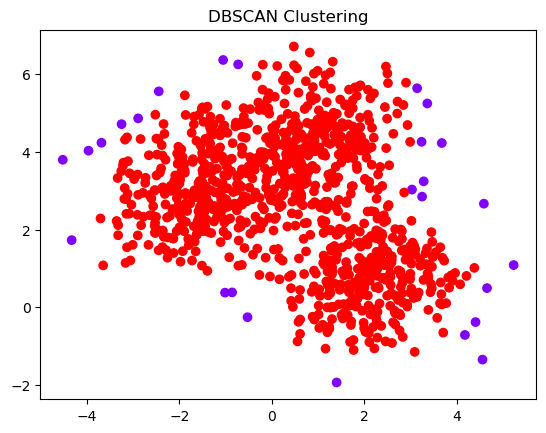

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs # import make_blobs dataset from scikit-learn
from sklearn.cluster import DBSCAN # import DBSCAN clustering algorithm from scikit-learn

# Generate sample dataset
X, y = make_blobs(n_samples=1000, centers=3, n_features=2, random_state=0)
# create 1000 data points in 2 dimensions with 3 clusters using make_blobs function from scikit-learn

# Run DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5) # create an instance of DBSCAN with parameters
epsilon=0.5 
min_samples=5
dbscan.fit(X) # fit DBSCAN model to the data

# Get cluster labels
labels = dbscan.labels_ # get cluster labels from DBSCAN model

# Plot the results
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='rainbow') # plot the data points with different colors for different clusters
plt.title('DBSCAN Clustering') # set the title of the plot
plt.show() # show the plot

# Making Own DBScan Algorithm

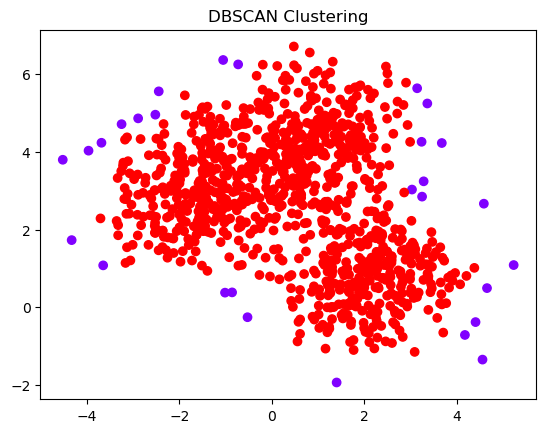

In [5]:
import numpy as np

def euclidean_distance(x, y):
    return np.sqrt(np.sum((x - y) ** 2))

def region_query(data, point_index, eps):
    neighbors = []
    for i in range(len(data)):
        if i != point_index:
            distance = euclidean_distance(data[i], data[point_index])
            if distance < eps:
                neighbors.append(i)
    return neighbors

def expand_cluster(data, labels, point_index, neighbors, cluster_id, eps, min_samples):
    labels[point_index] = cluster_id
    i = 0
    while i < len(neighbors):
        p = neighbors[i]
        if labels[p] == -1:
            labels[p] = cluster_id
        elif labels[p] == 0:
            labels[p] = cluster_id
            p_neighbors = region_query(data, p, eps)
            if len(p_neighbors) >= min_samples:
                neighbors = neighbors + p_neighbors
        i += 1

def dbscan(data, eps, min_samples):
    labels = np.zeros(len(data))
    cluster_id = 0
    for i in range(len(data)):
        if labels[i] != 0:
            continue
        neighbors = region_query(data, i, eps)
        if len(neighbors) < min_samples:
            labels[i] = -1
        else:
            cluster_id += 1
            expand_cluster(data, labels, i, neighbors, cluster_id, eps, min_samples)
    return labels

# Generate sample dataset
X, y = make_blobs(n_samples=1000, centers=3, n_features=2, random_state=0)
# create 1000 data points in 2 dimensions with 3 clusters using make_blobs function from scikit-learn

# Run DBSCAN
epsilon=0.5 
min_samples=5
labels = dbscan(X, epsilon, min_samples)

# Plot the results
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='rainbow') # plot the data points with different colors for different clusters
plt.title('DBSCAN Clustering') # set the title of the plot
plt.show() # show the plot